# IET SMP Assignment: Variational Autoencoders (VAE) with MNIST

**Total Marks: 20**

**Instructions:**
- Read each question carefully.
- Write the required code and brief explanations in the notebook cells provided.
- Run all code cells after completing the assignment.
- Keep your answers clear, concise, and well-organized.

### Assignment Overview
This notebook is structured as a short practical assignment on Variational Autoencoders using the MNIST dataset. You will define the model, train it, and generate new handwritten digit samples.

### Mark Distribution
- Concept of VAE and latent space: **3 marks**
- Encoder design and reparameterization trick: **5 marks**
- VAE loss function: **4 marks**
- Training setup and loop: **5 marks**
- Generating new digits and interpretation: **3 marks**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Question 1: VAE Concept, Encoder Design, and Reparameterization Trick [8 marks]

Explain the purpose of a Variational Autoencoder and how its latent space differs from that of a standard autoencoder.

Then describe how the VAE encoder produces the latent distribution parameters and why the reparameterization trick is required for backpropagation.

In your answer, include:
- the role of mean ($\mu$)
- the role of log-variance ($\log(\sigma^2)$)
- how $z = \mu + \sigma \odot \epsilon$ supports training

VAE is a generative model that learns from a compressed representation of data and generates new samples by sampling from a learned latent distribution. It tries to create a smooth latent space. It learns a range of values in the latent space, rather than fixed coordinates.

A standard autoencoder maps each input to a single point coordinate in latent space. They may be irregularly distributed, making random sampling difficult.

A VAE maps each input to a probability distribution in latent space. This creates a continuous, structured latent space where nearby points represent similar data, allowing new samples to be generated by takin samples from the distribution.

The VAE encoder outputs a mean (μ) and log-variance (log(σ^2)) that define a distribution in the latent space. The mean determines the center of the distribution, while the log-variance determines the spread about the mean. Instead of sampling directly, the VAE uses z=μ+σ.ϵ, where ϵ∼N(0,1). This reparameterization trick makes the sampling process differentiable, allowing backpropagation to train the encoder.

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # TODO: define the encoder layers here
        # TODO: define the latent mean and log-variance layers here
        # TODO: define the decoder layers here

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # TODO: flatten the input and pass it through the encoder
        # TODO: return the latent mean and log-variance
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        # TODO: sample epsilon and apply the reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        # TODO: map the latent vector back to the image space
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        # TODO: connect encode -> reparameterize -> decode
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon_x = self.decode(z)

        return recon_x, mu, logvar


# TODO: instantiate the model after completing the class
model = VAE().to(device)
print("VAE template ready for student implementation")


VAE template ready for student implementation


### Question 2: VAE Loss Function [4 mark]

Write the loss function for the VAE and briefly explain the purpose of each term.

Your response should include:
- reconstruction loss using binary cross entropy
- KL divergence and why it is needed

loss function = reconstruction loss + kle diveregnce. 

Rl compares the reconstructed image with the original and measures how accurately the VAE has reconstructed the input.

kl divergence measures how close the learned latent distribution is to a standard normal distribution N(0,1). It is needed to create a smooth, continuous latent space that allows good sampling and generation of new data.

In [8]:
def vae_loss(recon_x, x, mu, logvar):
    # TODO: compute the reconstruction loss

    x = x.view(x.size(0), -1)
    
    recon_loss = F.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    )
    # TODO: compute the KL divergence term

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    # TODO: return the total VAE loss

    return recon_loss + kl_loss
    


### Question 3: Training the VAE on MNIST [5 marks]

Complete the training setup for the MNIST dataset and train the model for the required number of epochs.

Include:
- dataset loading and preprocessing
- optimizer selection
- forward pass, loss calculation, and parameter updates

In [9]:
# Hyperparameters
# TODO: choose appropriate batch size, number of epochs, and learning rate
batch_size = 128
epochs = 15
learning_rate = 1e-3

# Data transformation and loading
# TODO: add any preprocessing needed for MNIST
transform = transforms.ToTensor()
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# TODO: create the optimizer after the model has been defined
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

# Training Loop
# TODO: complete the training loop
# Hint: move data to device, run the model, compute the loss, backpropagate, and update weights
model.train()

for epoch in range(epochs):

    train_loss = 0

    for data, _ in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = vae_loss(
            recon_batch,
            data,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {train_loss / len(train_loader.dataset):.4f}"
    )

Epoch 1/15, Loss: 164.0264
Epoch 2/15, Loss: 121.2577
Epoch 3/15, Loss: 114.5090
Epoch 4/15, Loss: 111.6456
Epoch 5/15, Loss: 109.8354
Epoch 6/15, Loss: 108.7022
Epoch 7/15, Loss: 107.8497
Epoch 8/15, Loss: 107.2196
Epoch 9/15, Loss: 106.7140
Epoch 10/15, Loss: 106.2940
Epoch 11/15, Loss: 105.9177
Epoch 12/15, Loss: 105.5852
Epoch 13/15, Loss: 105.2970
Epoch 14/15, Loss: 105.1310
Epoch 15/15, Loss: 104.9251


### Question 4: Generating New Digits [3 mark]

Use the trained decoder to generate new handwritten digits from random latent vectors.

Then briefly comment on the quality of the generated samples and what this suggests about the learned latent space.

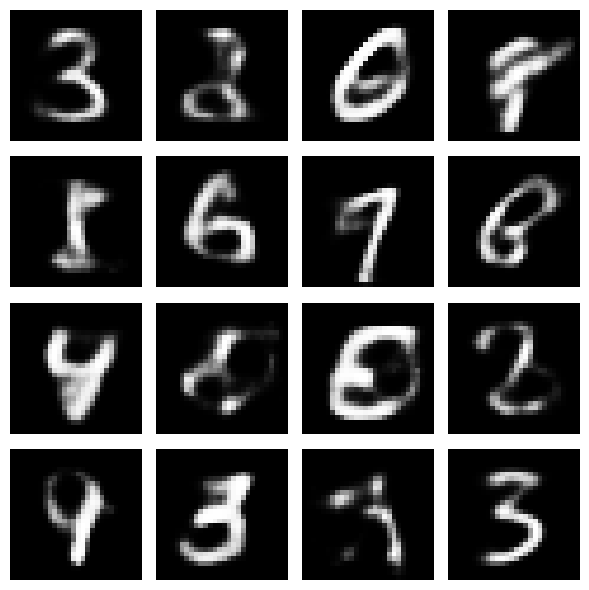

In [10]:
# TODO: write code to sample from the latent space using the trained decoder

model.eval()

with torch.no_grad():

    
    z = torch.randn(16, 20).to(device)

    samples = model.decode(z)

    samples = samples.view(-1, 1, 28, 28).cpu()

# TODO: visualize the generated digits

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()



The digits that have been generated are kind of recognizable but may appear blurry compared to the MNIST images we had earlier. This indicates that the VAE has learned a smooth and meaningful latent space, allowing random latent vectors to decode and produce digit-like images. The smooth latent space enables generation of new samples, although VAEs typically produce blurrier images than GANs due to the involvement of probability and the incorporation of the spread (std. dev.).